# Airbnb Rental Price & Availability Analysis






In [1]:
# Import the Liberaries
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the dataset


In [2]:
url = "https://www.kaggle.com/api/v1/datasets/download/dgomonov/new-york-city-airbnb-open-data"
headers = {"User-Agent": ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) ""AppleWebKit/537.36 (KHTML, like Gecko) ""Chrome/151.0.0.0 Safari/537.36")}
response = requests.get(url, headers=headers, timeout=60)
print( response.status_code)


200


In [3]:
import io
import zipfile

with zipfile.ZipFile(io.BytesIO(response.content)) as zip_file:
    csv_path = zip_file.extract("AB_NYC_2019.csv")

df = pd.read_csv(csv_path)

In [4]:
df = pd.read_csv("AB_NYC_2019.csv")
print( df.shape)
display(df.head())

(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

## 2. Select variables for the analysis


In [6]:
Data = df[[
    "name",
    "host_name",
    "neighbourhood_group",
    "neighbourhood",
    "room_type",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365"]].copy()

Data.rename(columns={
    "name": "Listing_Name",
    "host_name": "Host_Name",
    "neighbourhood_group": "Location",
    "neighbourhood": "Neighborhood",
    "room_type": "Room_Type",
    "price": "Price",
    "minimum_nights": "Minimum_Nights",
    "number_of_reviews": "Number_of_Reviews",
    "reviews_per_month": "Reviews_per_Month",
    "availability_365": "Availability"}, inplace=True)

Data_raw = Data.copy()
print( Data.shape)
display(Data.head(10))

(48895, 10)


,Listing_Name,Host_Name,Location,Neighborhood,Room_Type,Price,Minimum_Nights,Number_of_Reviews,Reviews_per_Month,Availability
0,Clean & quiet apt home by the park,John,Brooklyn,Kensington,Private room,149,1,9,0.21,365
1,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,Entire home/apt,225,1,45,0.38,355
2,THE VILLAGE OF HARLEM....NEW YORK !,Elisabeth,Manhattan,Harlem,Private room,150,3,0,NaN,365
3,Cozy Entire Floor of Brownstone,LisaRoxanne,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,4.64,194
4,Entire Apt: Spacious Studio/Loft by central park,Laura,Manhattan,East Harlem,Entire home/apt,80,10,9,0.10,0
5,Large Cozy 1 BR Apartment In Midtown East,Chris,Manhattan,Murray Hill,Entire home/apt,200,3,74,0.59,129
6,BlissArtsSpace!,Garon,Brooklyn,Bedford-Stuyvesant,Private room,60,45,49,0.40,0
7,Large Furnished Room Near B'way,Shunichi,Manhattan,Hell's Kitchen,Private room,79,2,430,3.47,220
8,Cozy Clean Guest Room - Family Apt,MaryEllen,Manhattan,Upper West Side,Private room,79,2,118,0.99,0
9,Cute & Cozy Lower East Side 1 bdrm,Ben,Manhattan,Chinatown,Entire home/apt,150,1,160,1.33,188


In [7]:
# Save a raw analysis subset before cleaning
Data_raw.to_csv("Airbnb_Raw_Data.csv", index=False)

# 3. Data Cleaning
1. Missing values
2. Duplicate listings
3. Price / numeric conversion
4. Date conversion
5. Location standardization
6. Outlier detection


In [8]:
# Missing-value before cleaning
missing_before = Data.isnull().sum().sort_values(ascending=False)
display(missing_before.to_frame("Missing_Count"))

,Missing_Count
Reviews_per_Month,10052
Host_Name,21
Listing_Name,16
Location,0
Neighborhood,0
Room_Type,0
Price,0
Minimum_Nights,0
Number_of_Reviews,0
Availability,0


In [9]:
# Duplicate using the original listing 
print("Duplicate Listing_Name values:", Data.duplicated(subset="Listing_Name").sum())
print("Exact duplicate rows:", Data.duplicated().sum())

# Keep one row per listing ID
Data = Data.drop_duplicates(subset="Listing_Name").copy()

Duplicate Listing_Name values: 989
Exact duplicate rows: 21


In [10]:
# Fill text fields and review rate
Data["Listing_Name"] = Data["Listing_Name"].fillna("Unknown")
Data["Host_Name"] = Data["Host_Name"].fillna("Unknown")

# A missing reviews/month value 
Data["Reviews_per_Month"] = Data["Reviews_per_Month"].fillna(0)

# Standardize text fields
for col in ["Location", "Neighborhood"]:
    Data[col] = (Data[col].astype("string").str.strip().str.replace(r"\s+", " ", regex=True).str.title())

Data["Room_Type"] = Data["Room_Type"].astype("string").str.strip()

In [11]:
# Convert numeric variables
numeric_columns = [
    "Price",
    "Minimum_Nights",
    "Number_of_Reviews",
    "Reviews_per_Month",
    "Availability"]

for col in numeric_columns:
    Data[col] = pd.to_numeric(Data[col], errors="coerce")

# Remove invalid values
Data = Data.dropna(subset=numeric_columns).copy()
Data = Data[
    (Data["Price"] > 0) &
    (Data["Minimum_Nights"] > 0) &
    (Data["Number_of_Reviews"] >= 0) &
    (Data["Reviews_per_Month"] >= 0) &
    (Data["Availability"].between(0, 365))].copy()

Data_clean = Data.reset_index(drop=True)

print( Data_clean.shape)
print("Remaining missing values:", int(Data_clean.isnull().sum().sum()))

(47895, 10)
Remaining missing values: 0


## 3.1 outliers


In [12]:
Q1 = Data_clean["Price"].quantile(0.25)
Q3 = Data_clean["Price"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

Data_no_outliers = Data_clean[Data_clean["Price"].between(max(0, lower_limit), upper_limit)].copy()

print(f"Q1: ${Q1:,.2f}")
print(f"Q3: ${Q3:,.2f}")
print(f"IQR: ${IQR:,.2f}")
print(f"IQR lower limit: ${lower_limit:,.2f}")
print(f"IQR upper limit: ${upper_limit:,.2f}")
print("Rows in cleaned dataset:", len(Data_clean))
print("Rows in price-analysis dataset after removing IQR outliers:", len(Data_no_outliers))
print("Price outliers removed:", len(Data_clean) - len(Data_no_outliers))

Q1: $69.00
Q3: $175.00
IQR: $106.00
IQR lower limit: $-90.00
IQR upper limit: $334.00
Rows in cleaned dataset: 47895
Rows in price-analysis dataset after removing IQR outliers: 44968
Price outliers removed: 2927


In [13]:
# Final cleaning checks
quality_check = pd.DataFrame({"Missing": Data_clean.isnull().sum(),"Dtype": Data_clean.dtypes.astype(str)})
display(quality_check)

,Missing,Dtype
Listing_Name,0,object
Host_Name,0,object
Location,0,string
Neighborhood,0,string
Room_Type,0,string
Price,0,int64
Minimum_Nights,0,int64
Number_of_Reviews,0,int64
Reviews_per_Month,0,float64
Availability,0,int64


In [14]:
# Save cleaned datasets
Data_clean.to_csv("Airbnb_Cleaned_Data.csv", index=False)
Data_no_outliers.to_csv("Airbnb_Cleaned_No_Outliers.csv", index=False)

# 4. Exploratory Data Analysis (EDA)
### Main questions
1. Which neighborhoods have the highest rental prices?
2. Entire home vs private room price?
3. Does number of reviews relate to price?
4. Which areas have highest availability?
5. Which hosts have the most listings?


## 1 Neighborhoods with the highest prices
.

In [15]:
# Top 10 neighborhoods with highest average prices

Top_10_neighborhoods = (
    Data_no_outliers
    .groupby(["Neighborhood", "Location"])
    .agg(
        Listings=("Price", "count"),
        Average_Price=("Price", "mean")
    )
    .reset_index()
    .sort_values("Average_Price", ascending=False)
    .head(10)
)

display(Top_10_neighborhoods.round(1))

,Neighborhood,Location,Listings,Average_Price
214,Willowbrook,Staten Island,1,249.0
138,Neponsit,Queens,2,237.0
21,Breezy Point,Queens,2,222.5
196,Tribeca,Manhattan,106,212.5
143,Noho,Manhattan,54,205.8
208,West Village,Manhattan,625,192.5
75,Flatiron District,Manhattan,54,190.0
73,Financial District,Manhattan,639,184.2
126,Midtown,Manhattan,1125,181.1
91,Greenwich Village,Manhattan,338,180.6


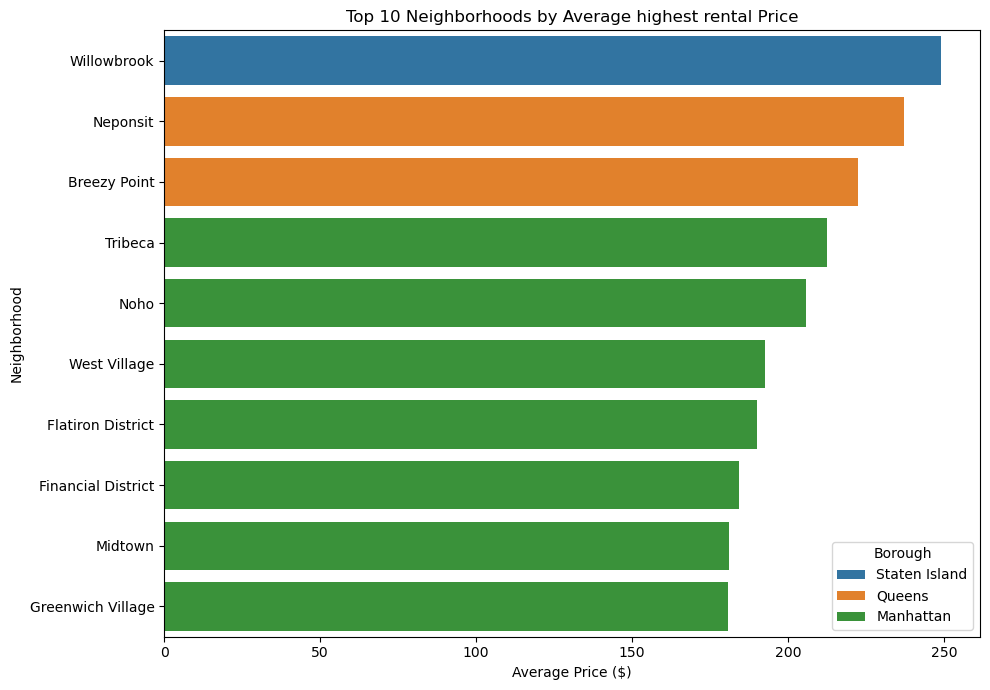

In [16]:
# Bar plot
plt.figure(figsize=(10, 7))
sns.barplot(
    data=Top_10_neighborhoods,
    y="Neighborhood",
    x="Average_Price",
    hue="Location",
    dodge=False)
plt.title("Top 10 Neighborhoods by Average highest rental Price")
plt.xlabel("Average Price ($)")
plt.ylabel("Neighborhood")
plt.legend(title="Borough")
plt.tight_layout()
plt.show()

## 2. Entire home vs private room price

In [17]:
room_price = (Data_no_outliers[Data_no_outliers["Room_Type"].isin(["Entire home/apt", "Private room"])]
    .groupby("Room_Type")["Price"]
    .agg(["mean", "median", "count"])
    .rename(columns={
        "mean": "Average_Price",
        "median": "Median_Price",
        "count": "Listings"}))

display(room_price.round(2))

,Average_Price,Median_Price,Listings
Room_Type,,,
Entire home/apt,162.52,150.0,22417
Private room,78.98,70.0,21442


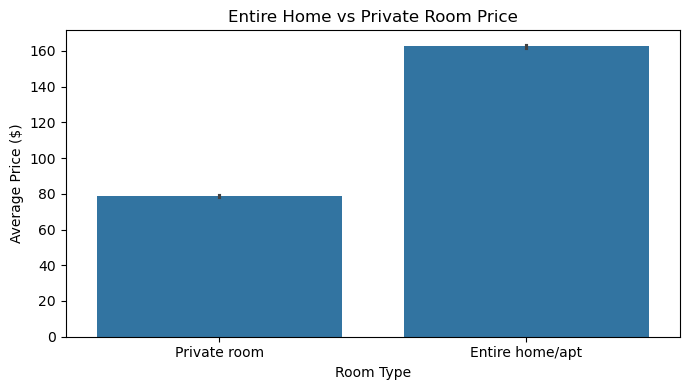

In [18]:
plt.figure(figsize=(7, 4))

sns.barplot(data=Data_no_outliers[Data_no_outliers["Room_Type"].isin(["Entire home/apt", "Private room"])],
    x="Room_Type",
    y="Price",
    estimator="mean")

plt.title("Entire Home vs Private Room Price")
plt.xlabel("Room Type")
plt.ylabel("Average Price ($)")
plt.tight_layout()
plt.show()

## 3. Does number of reviews relate to price

,Price,Number_of_Reviews,Reviews_per_Month
Price,1.000,-0.028,-0.047
Number_of_Reviews,-0.028,1.000,0.594
Reviews_per_Month,-0.047,0.594,1.000


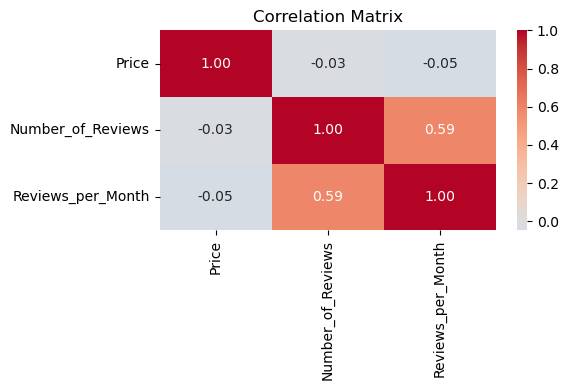

In [19]:
numeric_for_corr = Data_no_outliers[[
    "Price",
    "Number_of_Reviews",
    "Reviews_per_Month",]]

corr = numeric_for_corr.corr()

display(corr.round(3))

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 4. Which areas have highest availability

In [20]:
# Area with the highest availability
highest_availability_area = (
    Data_clean.groupby("Location")["Availability"]
    .agg(["mean", "median"])
    .sort_values("mean", ascending=False)
    .head(10)
    .rename(columns={
        "mean": "Average_Availability",
        "median": "Median_Availability"
    })
)

display(highest_availability_area.round(2))

,Average_Availability,Median_Availability
Location,,
Staten Island,198.85,216.0
Bronx,165.66,148.0
Queens,143.41,95.5
Manhattan,111.57,36.0
Brooklyn,100.42,28.0


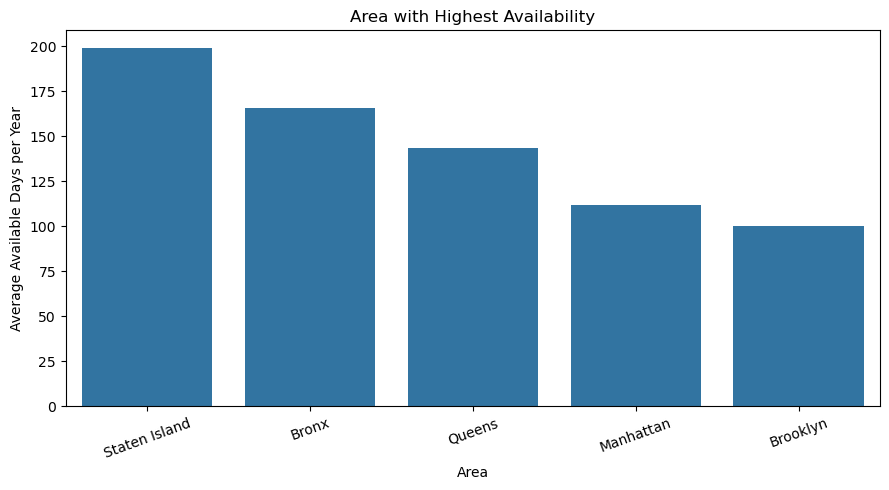

In [21]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=highest_availability_area.reset_index(),
    x="Location",
    y="Average_Availability"
)

plt.title("Area with Highest Availability")
plt.xlabel("Area")
plt.ylabel("Average Available Days per Year")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 5. Which hosts have the most listings

In [22]:
top_hosts = (
    Data_clean["Host_Name"]
    .value_counts()
    .head(10)
    .rename_axis("Host_Name")
    .reset_index(name="Listings"))

display(top_hosts)

,Host_Name,Listings
0,Michael,411
1,David,397
2,Sonder (NYC),311
3,John,292
4,Alex,275
5,Blueground,231
6,Daniel,223
7,Sarah,222
8,Maria,201
9,Jessica,200


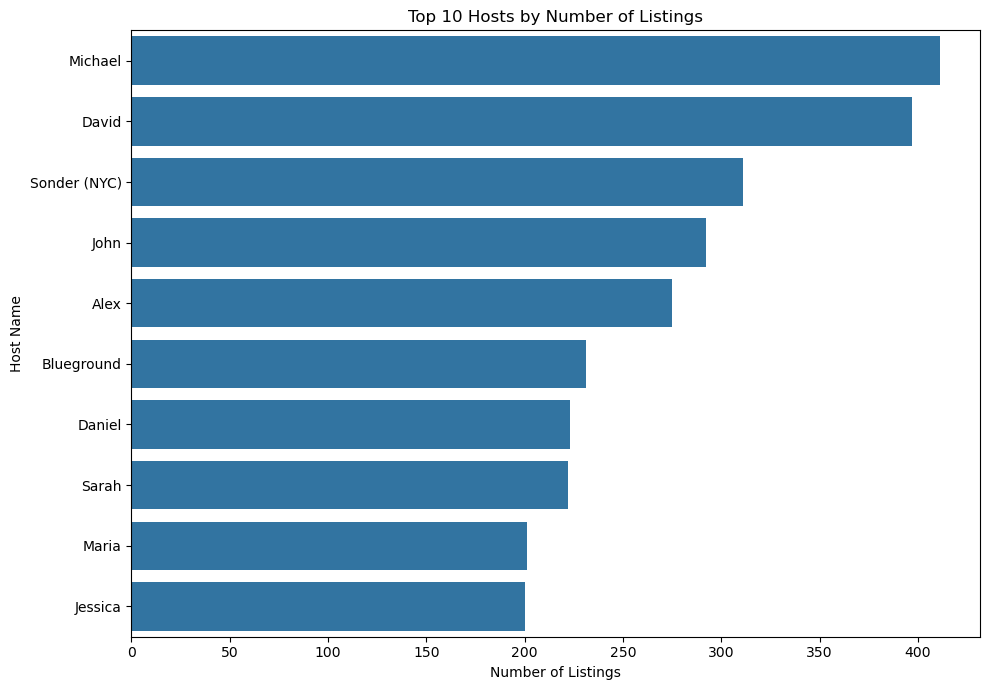

In [23]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_hosts,
    y="Host_Name",
    x="Listings"
)

plt.title("Top 10 Hosts by Number of Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Host Name")
plt.tight_layout()
plt.show()

# Key findings and conclusion

In [24]:
print("KEY FINDINGS")

print("1. Highest Price:")
print("   Willowbrook has the highest average price at $249/night.")
print("   However, it has only 1 listing; Tribeca is a more representative high-price neighborhood at $212.5/night.")

print("\n2. Entire Home vs Private Room:")
print("   Entire home/apt: $162.52 average price")
print("   Private room: $78.98 average price")
print("   Entire homes are about twice as expensive as private rooms.")

print("\n3. Reviews vs Price:")
print("   Correlation = -0.028")
print("   Therefore, number of reviews has almost no relationship with price.")

print("\n4. Highest Availability:")
print("   Staten Island has the highest average availability at 198.85 days/year.")

print("\n5. Hosts with Most Listings:")
print("   Michael has the most listings (411), followed by David (397) and Sonder (NYC) (311).")

print("\nCONCLUSION")

print("Airbnb prices are mainly influenced by location and room type.")
print("Entire homes are considerably more expensive than private rooms.")
print("Reviews have very little relationship with price, while availability varies strongly by area.")

KEY FINDINGS
1. Highest Price:
   Willowbrook has the highest average price at $249/night.
   However, it has only 1 listing; Tribeca is a more representative high-price neighborhood at $212.5/night.

2. Entire Home vs Private Room:
   Entire home/apt: $162.52 average price
   Private room: $78.98 average price
   Entire homes are about twice as expensive as private rooms.

3. Reviews vs Price:
   Correlation = -0.028
   Therefore, number of reviews has almost no relationship with price.

4. Highest Availability:
   Staten Island has the highest average availability at 198.85 days/year.

5. Hosts with Most Listings:
   Michael has the most listings (411), followed by David (397) and Sonder (NYC) (311).

CONCLUSION
Airbnb prices are mainly influenced by location and room type.
Entire homes are considerably more expensive than private rooms.
Reviews have very little relationship with price, while availability varies strongly by area.


# Files Generated by the Notebook
##### Airbnb_Raw_Data.csv
##### Airbnb_Cleaned_Data.csv
##### Airbnb_Cleaned_No_Outliers.csv